# Rare-Disease Synthetic Data Augmentation — Day 5: Stress-testing the result

Day 4 showed that adding *new* rare-class images (GAN, SMOTE, classic augmentation) beats the baseline, while plain
copies do not. Today we test that result against the two questions a reviewer would ask:

| Part | Question | How | Time |
|---|---|---|---|
| **A** | *"Couldn't you just lower the decision threshold instead of making new images?"* | Re-load all 15 Day 4 models, choose a DF threshold on **validation**, apply it once to **test** | ~3 min |
| **B** | *"Does this only work for one disease?"* | Repeat the whole study on a second rare disease, **VASC** (vascular lesions): new GAN + SMOTE set | ~35–45 min |
| **C** | | 5 methods × 3 seeds on VASC | ~55 min |
| **D** | | VASC results, and the threshold test on VASC | ~3 min |
| **E** | | Both diseases side by side | — |

Same data split, same classifier recipe, same 500-extra-images budget as Days 1–4. Nothing from the DF study is retrained or changed.

**How to run:** `Kernel → Restart & Run All` (or `Cell → Run All`). Total ≈ 1.5–2 hours; you can leave the laptop running
(plugged in, sleep off). **If anything stops, just run all again** — the GAN resumes from its last checkpoint and finished
training runs are skipped.

## 0 · Setup

In [1]:
import os, sys
from pathlib import Path

# The project folder is the one this notebook sits in: C:\rare-disease-aug\notebooks -> C:\rare-disease-aug
PROJECT_DIR = Path(os.environ.get('RDA_PROJECT_DIR',
                   str(Path.cwd().parent if (Path.cwd().parent / 'src').exists() else Path.cwd())))
RAW_DIR = PROJECT_DIR / 'data' / 'raw'          # not needed today
SRC = PROJECT_DIR / 'src'
checks = {'threshold.py (new)': (SRC / 'threshold.py').exists(),
          'experiments.py (updated)': 'run_dir_for' in (SRC / 'experiments.py').read_text(encoding='utf-8'),
          'analysis.py (updated)': 'plot_two_diseases' in (SRC / 'analysis.py').read_text(encoding='utf-8'),
          'compare.py (updated)': 'rare: str = "DF"' in (SRC / 'compare.py').read_text(encoding='utf-8')}
for name, ok in checks.items():
    print(('OK      ' if ok else 'MISSING ') + 'src/' + name)
assert all(checks.values()), 'Some Day 5 files are not in C:\\rare-disease-aug\\src yet - see the list above'
os.chdir(PROJECT_DIR)
sys.path.insert(0, str(PROJECT_DIR))
print('Project dir:', PROJECT_DIR)

OK      src/threshold.py (new)
OK      src/experiments.py (updated)
OK      src/analysis.py (updated)
OK      src/compare.py (updated)
Project dir: C:\rare-disease-aug


In [2]:
import json
import numpy as np, pandas as pd, torch, matplotlib.pyplot as plt
from IPython.display import display

from src.config import Paths, CLASS_CODES, CLASS_NAMES
from src.data.explore import build_metadata
from src.data.split import make_split
from src.data.preprocess import build_image_cache
from src.data.dataset import attach_cache_index
from src.augment import smote_rare_images
from src.experiments import CONFIGS, CONFIG_ORDER, run_config, completed_runs, synthetic_path, run_dir_for
from src.analysis import (load_log, seed_summary, paired_vs_baseline, plot_seed_comparison, load_predictions,
                          per_image_hits, false_positive_sources, shortcut_table, plot_two_diseases)
from src.threshold import threshold_study, threshold_summary, paired_tuned, plot_threshold_effect
from src.fid import inception_features, fid_from_features, matched_fid
from src.gan.trainer import GANConfig, train_gan, generate, load_generator, resize_uint8
from src.gan.filtering import select_synthetic, real_real_nn, gen_real_nn
from src.gan.viz import show_image, image_rows, numbered_grid, plot_gan_history, plot_nn_distances

pd.set_option('display.width', 180)
pd.set_option('display.max_columns', 30)
paths = Paths(PROJECT_DIR, RAW_DIR)
FIG = paths.figures_dir
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'torch {torch.__version__} | device: {DEVICE}' + (f' ({torch.cuda.get_device_name(0)})' if DEVICE.type == 'cuda' else ''))
if DEVICE.type != 'cuda':
    print('WARNING: no GPU found - this notebook would take many hours on the CPU. Stop and tell Claude.')

torch 2.14.0+cu126 | device: cuda (NVIDIA GeForce RTX 4060 Laptop GPU)


## 1 · Load the data (the same fixed split as Days 1–4)

In [3]:
meta = build_metadata(paths)
split = make_split(meta, paths, seed=42)
images = build_image_cache(meta, paths, size=224)
split = attach_cache_index(split, meta)
train_df = split[split.split == 'train'].reset_index(drop=True)

DF, VASC = 'DF', 'VASC'
N_EXTRA = 500
EPOCHS = 15          # same recipe as Days 1-4 - do not change
PRETRAINED = True
SEEDS = [42, 43, 44]

counts = split.groupby(['label', 'split']).size().unstack()[['train', 'val', 'test']]
counts['share of all images'] = (counts.sum(axis=1) / len(split)).map('{:.2%}'.format)
display(counts.loc[[DF, VASC]])

[reuse] raw data not on disk; loading saved C:\rare-disease-aug\data\processed\metadata.csv
[reuse] existing split C:\rare-disease-aug\data\splits\split_seed42.csv
[reuse] image cache C:\rare-disease-aug\data\processed\images_224px_uint8.npy  shape=(10015, 224, 224, 3)
Loading images_224px_uint8.npy into RAM ...


split,train,val,test,share of all images
label,,,,
DF,71,24,20,1.15%
VASC,99,22,21,1.42%


## 2 · Part A — the threshold baseline (DF)

Every model normally predicts the class with the highest probability. A cheaper fix for a rare class is to predict it
**whenever its probability passes a lower threshold**. If that alone matched the GAN, the new images would not be needed.

For each of the 15 Day 4 models: load the saved model → pick the DF threshold with the best F1 on **validation** →
apply it once to **test**. The *AP* column (average precision) scores the model at every threshold at once, so it
shows whether a method is genuinely better at *recognising* DF, not just at where it draws the line.

⚠️ The validation set has only 24 DF images, so the chosen threshold is itself noisy — that's the honest version of this test.

In [4]:
log_df = load_log(paths, DF)
have = pd.DataFrame([['✅' if (run_dir_for(paths, c, s, DF) / 'best.pt').exists() else 'missing' for s in SEEDS]
                     for c in CONFIG_ORDER], index=[CONFIGS[c]['label'] for c in CONFIG_ORDER],
                    columns=[f'seed {s}' for s in SEEDS])
print(f'Saved DF models (best.pt) found:')
display(have)

Saved DF models (best.pt) found:


,seed 42,seed 43,seed 44
Baseline (no aug),✅,✅,✅
Oversample only,✅,✅,✅
Classic aug,✅,✅,✅
SMOTE interp.,✅,✅,✅
GAN aug,✅,✅,✅


In [5]:
study_df = threshold_study(paths, log_df, images, split, DF, DEVICE)
study_df.to_csv(paths.results_dir / 'day5_threshold_DF_runs.csv', index=False)
thr_df = threshold_summary(study_df, DF)
thr_df.to_csv(paths.results_dir / 'day5_threshold_DF.csv')
display(thr_df)

Baseline (no aug)  seed 42: threshold 0.45 | test DF F1 0.50 (default) -> 0.53 (tuned) | caught 9 -> 9
Baseline (no aug)  seed 43: threshold 0.06 | test DF F1 0.48 (default) -> 0.61 (tuned) | caught 7 -> 15
Baseline (no aug)  seed 44: threshold 0.06 | test DF F1 0.59 (default) -> 0.58 (tuned) | caught 10 -> 16
Oversample only    seed 42: threshold 0.31 | test DF F1 0.52 (default) -> 0.63 (tuned) | caught 8 -> 11
Oversample only    seed 43: threshold 0.21 | test DF F1 0.62 (default) -> 0.71 (tuned) | caught 10 -> 12
Oversample only    seed 44: threshold 0.46 | test DF F1 0.45 (default) -> 0.43 (tuned) | caught 7 -> 6
Classic aug        seed 42: threshold 0.79 | test DF F1 0.61 (default) -> 0.69 (tuned) | caught 14 -> 12
Classic aug        seed 43: threshold 0.26 | test DF F1 0.55 (default) -> 0.53 (tuned) | caught 11 -> 12
Classic aug        seed 44: threshold 0.56 | test DF F1 0.70 (default) -> 0.71 (tuned) | caught 13 -> 12
SMOTE interp.      seed 42: threshold 0.34 | test DF F1 0.56 

,seeds,DF F1 — default,DF F1 — tuned threshold,recall — tuned,precision — tuned,false alarms / run — tuned,threshold (mean),DF AP (threshold-free)
method,,,,,,,,
Baseline (no aug),3,0.524 ± 0.057,0.574 ± 0.042,0.667 ± 0.189,0.539 ± 0.095,12.7,0.19,0.615 ± 0.062
Oversample only,3,0.531 ± 0.088,0.588 ± 0.143,0.483 ± 0.161,0.780 ± 0.067,2.7,0.33,0.692 ± 0.045
Classic aug,3,0.620 ± 0.077,0.642 ± 0.094,0.600 ± 0.000,0.712 ± 0.203,6.0,0.54,0.681 ± 0.034
SMOTE interp.,3,0.637 ± 0.071,0.650 ± 0.075,0.617 ± 0.076,0.693 ± 0.111,5.7,0.30,0.689 ± 0.026
GAN aug,3,0.656 ± 0.062,0.626 ± 0.049,0.667 ± 0.202,0.675 ± 0.220,9.3,0.25,0.734 ± 0.051


Every method with a TUNED threshold vs the baseline with a TUNED threshold (same seed), change in DF F1:


,seed 42,seed 43,seed 44,mean change,better,same,worse
method,,,,,,,
Oversample only,0.099,0.094,-0.153,0.013,2,0,1
Classic aug,0.156,-0.079,0.124,0.067,2,0,1
SMOTE interp.,0.156,-0.048,0.118,0.075,2,0,1
GAN aug,0.154,-0.012,0.015,0.052,2,0,1


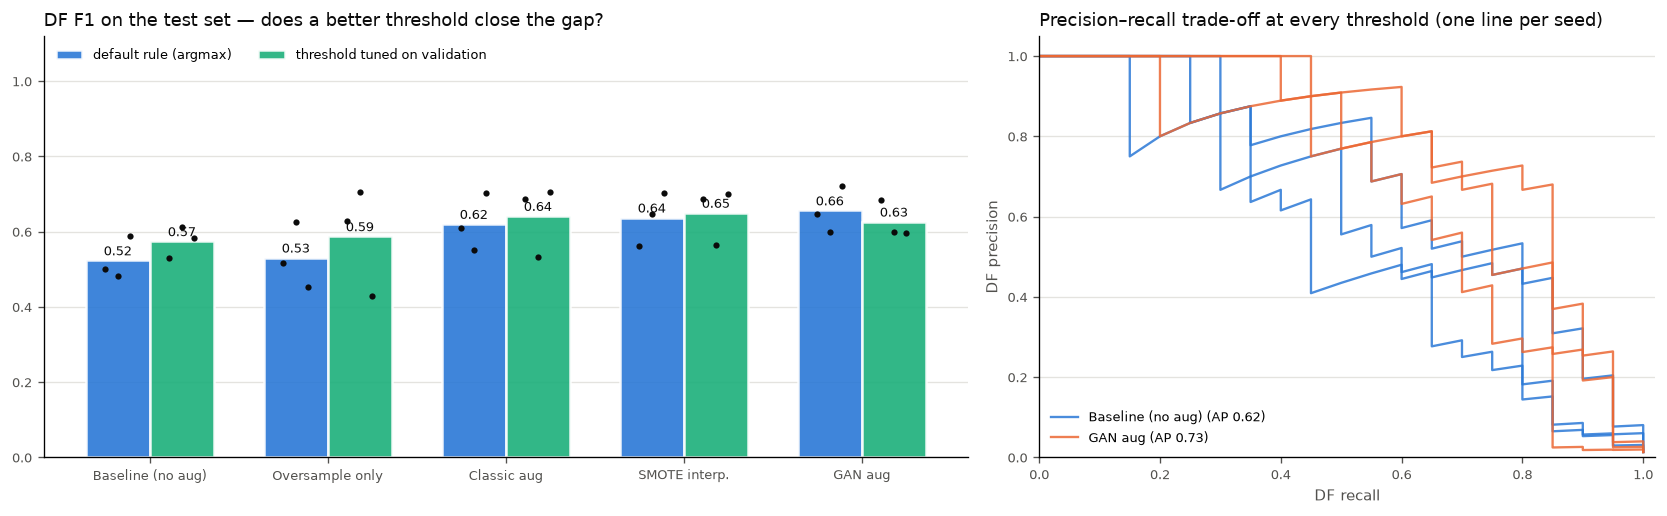

In [6]:
print(f'Every method with a TUNED threshold vs the baseline with a TUNED threshold (same seed), change in {DF} F1:')
paired_thr_df = paired_tuned(study_df)
display(paired_thr_df)
plot_threshold_effect(study_df, paths, DF, FIG / 'day5_threshold_DF.png')

**How to read this:** compare the teal bars. If the tuned baseline reaches the GAN's level, most of the Day 4 gain was
"where the line is drawn". If the GAN stays ahead even when *both* are tuned — and its AP is higher — the new images taught
the model something the threshold can't.

## 3 · Part B — a second rare disease: VASC (vascular lesions)

VASC is the other class under 2 % of the data. It looks quite different from DF (red/purple, blood-vessel patterns), so
it's a fair test of whether the method carries over. First, the real VASC training images:

VASC training images: 99 from 69 lesions | held-out (val+test, FID only): 43


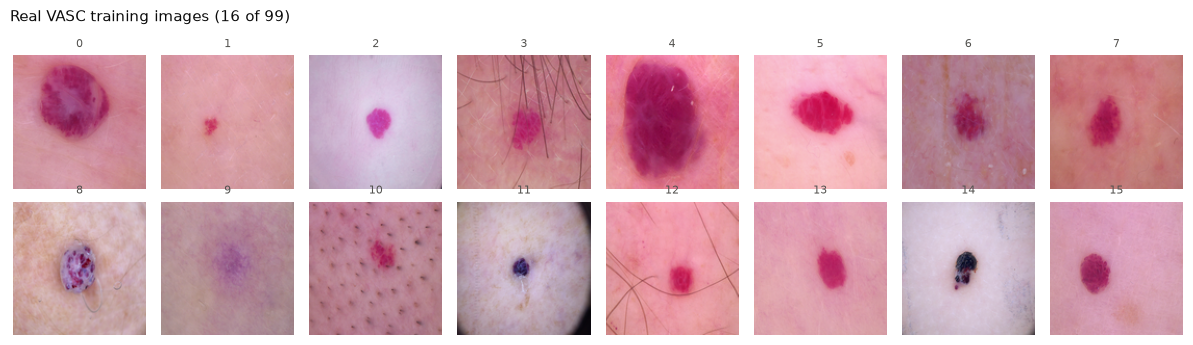

In [7]:
VASC_IDX = CLASS_CODES.index(VASC)
train_v = split[(split.split == 'train') & (split.label == VASC)].reset_index(drop=True)
heldout_v = split[(split.split != 'train') & (split.label == VASC)].reset_index(drop=True)   # FID reference only
IMG = 128
real128_v = resize_uint8(np.stack([images[i] for i in train_v.cache_idx]), IMG)
heldout128_v = resize_uint8(np.stack([images[i] for i in heldout_v.cache_idx]), IMG)
lesions_v = train_v.lesion_id.to_numpy()
print(f'VASC training images: {len(real128_v)} from {len(set(lesions_v))} lesions | held-out (val+test, FID only): {len(heldout128_v)}')
numbered_grid(real128_v[:16], f'Real {VASC} training images (16 of {len(real128_v)})', out=FIG / 'day5_vasc_real_examples.png')

### 3a · SMOTE blends for VASC (same method as Day 2)

Saved 500 SMOTE VASC images


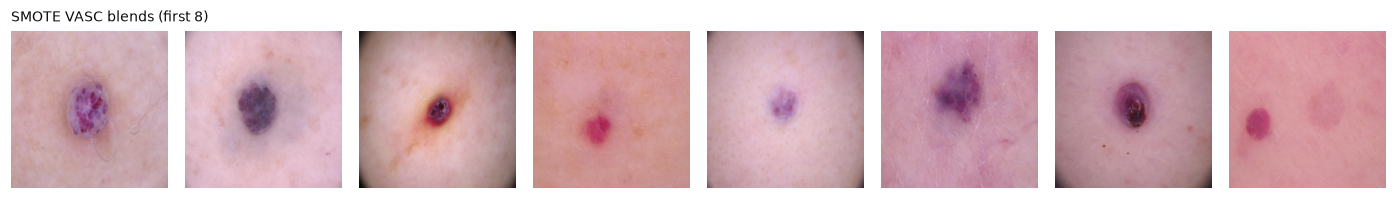

In [8]:
syn_dir = paths.project_dir / 'data' / 'synthetic'
syn_dir.mkdir(parents=True, exist_ok=True)
smote_file = synthetic_path(paths, 'smote', VASC, N_EXTRA)
if smote_file.exists():
    smote_v = np.load(smote_file)
    print('Already made - loaded', smote_file.name)
else:
    smote_v, smote_prov_v = smote_rare_images(images, train_df, VASC_IDX, N_EXTRA, k=5, seed=42, feature_space='resnet')
    np.save(smote_file, smote_v)
    smote_prov_v.to_csv(syn_dir / f'smote_{VASC}_{N_EXTRA}_provenance.csv', index=False)
    print(f'Saved {len(smote_v)} SMOTE {VASC} images')
image_rows([smote_v[:8]], [f'SMOTE {VASC} blends (first 8)'])

### 3b · Train the VASC GAN (same settings as the DF GAN on Day 3)

A sample grid appears every 2,000 iterations. Expect ~25–40 min on the RTX 4060. If it stops, run all again — it resumes.

Downloading: "https://github.com/mseitzer/pytorch-fid/releases/download/fid_weights/pt_inception-2015-12-05-6726825d.pth" to C:\Users\ASUS/.cache\torch\hub\checkpoints\pt_inception-2015-12-05-6726825d.pth


100%|██████████| 91.2M/91.2M [00:29<00:00, 3.22MB/s]


Reference FID (real held-out VASC vs real training VASC): 119.8
Real images: 99 | G params 2.65M | D params 2.80M | device cuda | iterations 0 -> 20000
it    500/20000 | D 1.595 G 0.474 | r_t 0.57 | 0.7 min, ETA 28.5 min
it   1000/20000 | D 1.793 G 0.219 | r_t 0.51 | 1.4 min, ETA 27.3 min
it   1500/20000 | D 1.804 G 0.217 | r_t 0.52 | 2.1 min, ETA 26.5 min


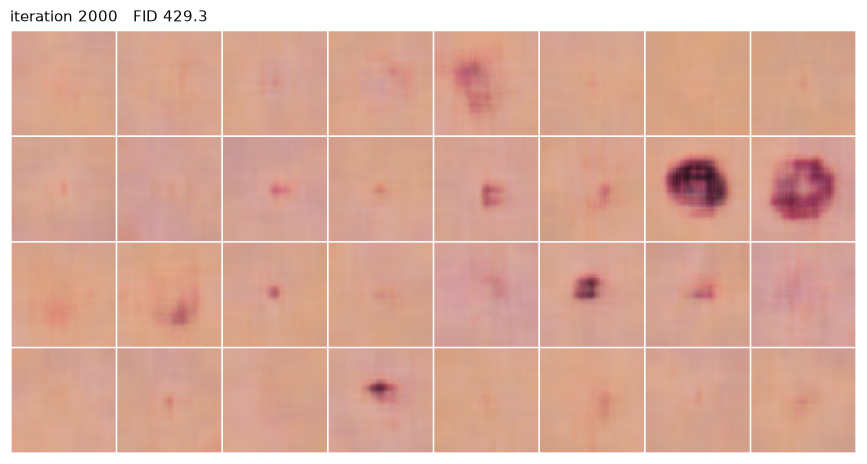

it   2000/20000 | D 1.801 G 0.207 | r_t 0.54 | FID 429.3 | 2.9 min, ETA 26.1 min
it   2500/20000 | D 1.876 G 0.144 | r_t 0.49 | 3.6 min, ETA 25.4 min
it   3000/20000 | D 1.905 G 0.150 | r_t 0.47 | 4.4 min, ETA 25.0 min
it   3500/20000 | D 1.931 G 0.137 | r_t 0.46 | 5.2 min, ETA 24.4 min


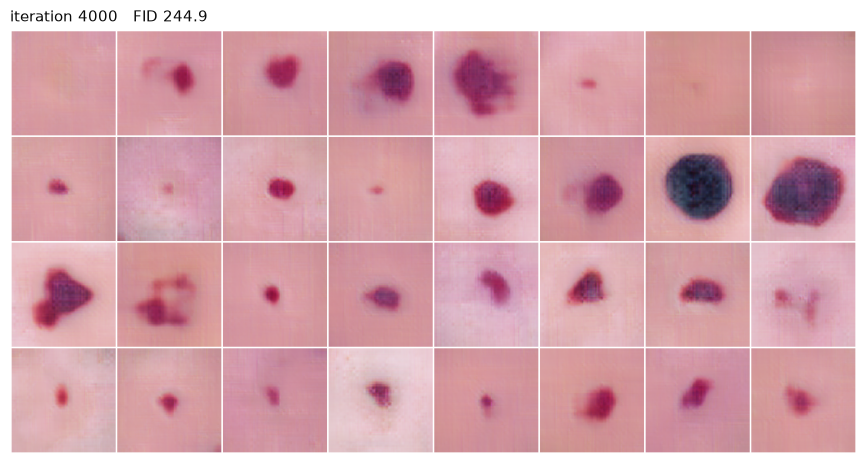

it   4000/20000 | D 1.938 G 0.115 | r_t 0.46 | FID 244.9 | 5.9 min, ETA 23.6 min
it   4500/20000 | D 1.930 G 0.110 | r_t 0.48 | 6.6 min, ETA 22.8 min
it   5000/20000 | D 1.923 G 0.099 | r_t 0.50 | 7.3 min, ETA 21.9 min
it   5500/20000 | D 1.910 G 0.128 | r_t 0.48 | 8.0 min, ETA 21.2 min


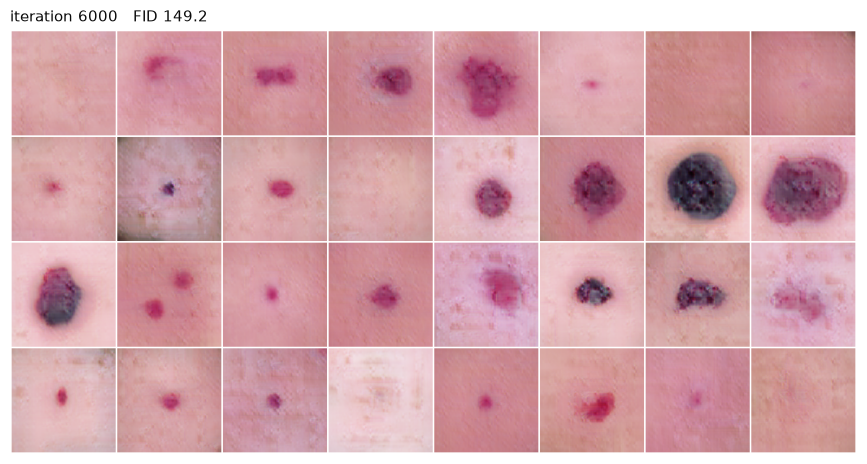

it   6000/20000 | D 1.914 G 0.129 | r_t 0.48 | FID 149.2 | 8.8 min, ETA 20.4 min
it   6500/20000 | D 1.900 G 0.139 | r_t 0.47 | 9.5 min, ETA 19.7 min
it   7000/20000 | D 1.892 G 0.131 | r_t 0.49 | 10.2 min, ETA 18.9 min
it   7500/20000 | D 1.893 G 0.141 | r_t 0.48 | 10.9 min, ETA 18.1 min


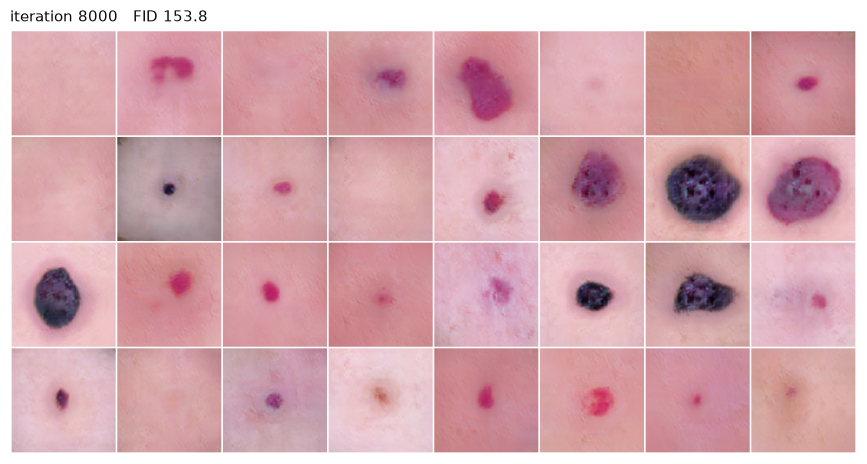

it   8000/20000 | D 1.889 G 0.146 | r_t 0.49 | FID 153.8 | 11.6 min, ETA 17.4 min
it   8500/20000 | D 1.889 G 0.163 | r_t 0.47 | 12.3 min, ETA 16.7 min
it   9000/20000 | D 1.878 G 0.136 | r_t 0.49 | 13.0 min, ETA 15.9 min
it   9500/20000 | D 1.888 G 0.140 | r_t 0.48 | 13.7 min, ETA 15.2 min


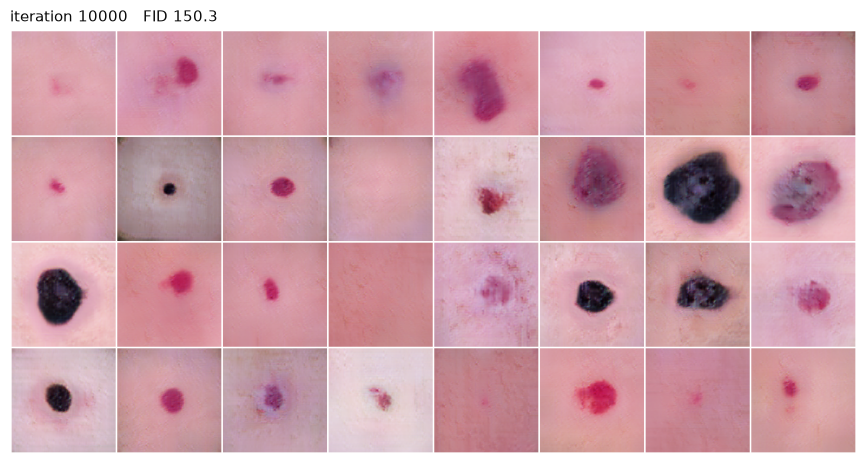

it  10000/20000 | D 1.880 G 0.144 | r_t 0.50 | FID 150.3 | 14.5 min, ETA 14.5 min
it  10500/20000 | D 1.865 G 0.130 | r_t 0.50 | 15.2 min, ETA 13.8 min
it  11000/20000 | D 1.877 G 0.165 | r_t 0.48 | 16.0 min, ETA 13.1 min
it  11500/20000 | D 1.859 G 0.160 | r_t 0.49 | 16.7 min, ETA 12.3 min


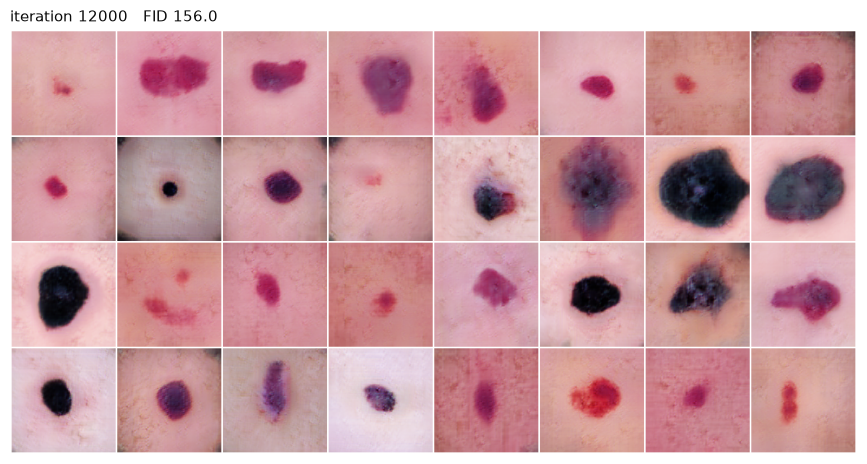

it  12000/20000 | D 1.853 G 0.156 | r_t 0.49 | FID 156.0 | 17.4 min, ETA 11.6 min
it  12500/20000 | D 1.847 G 0.182 | r_t 0.49 | 18.2 min, ETA 10.9 min
it  13000/20000 | D 1.837 G 0.185 | r_t 0.49 | 18.9 min, ETA 10.2 min
it  13500/20000 | D 1.834 G 0.183 | r_t 0.50 | 19.8 min, ETA 9.5 min


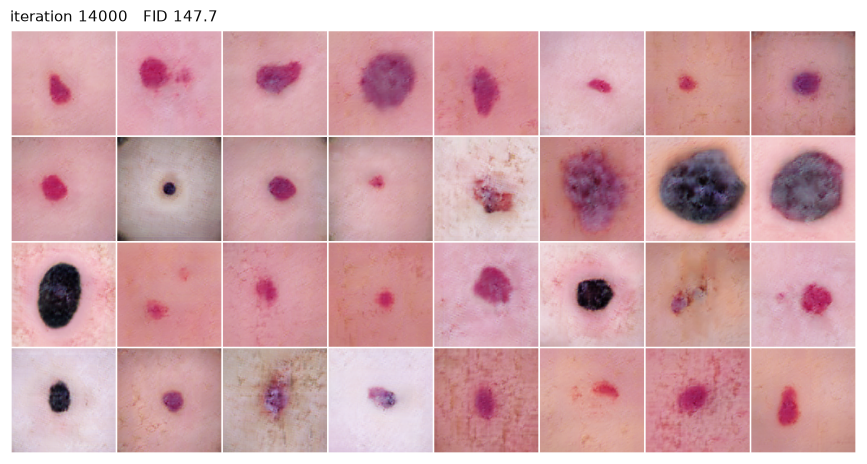

it  14000/20000 | D 1.835 G 0.185 | r_t 0.49 | FID 147.7 | 20.5 min, ETA 8.8 min
it  14500/20000 | D 1.827 G 0.187 | r_t 0.50 | 21.3 min, ETA 8.1 min
it  15000/20000 | D 1.828 G 0.178 | r_t 0.50 | 22.0 min, ETA 7.3 min
it  15500/20000 | D 1.825 G 0.200 | r_t 0.49 | 22.7 min, ETA 6.6 min


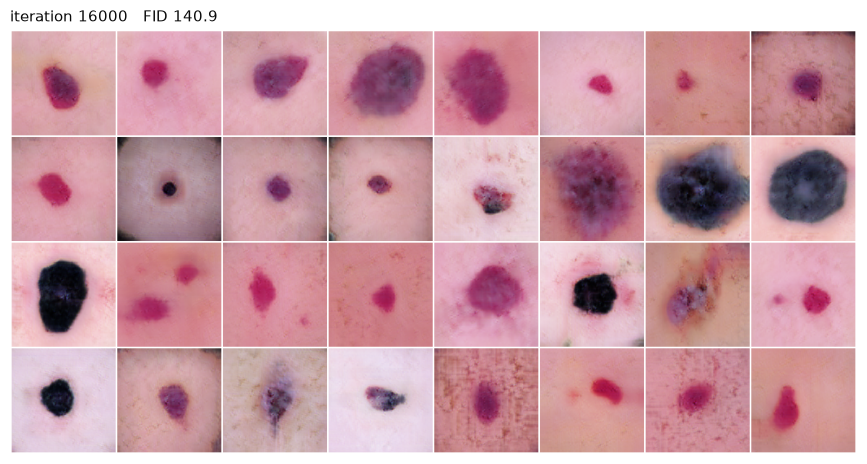

it  16000/20000 | D 1.826 G 0.227 | r_t 0.46 | FID 140.9 | 23.4 min, ETA 5.9 min
it  16500/20000 | D 1.820 G 0.182 | r_t 0.49 | 24.1 min, ETA 5.1 min
it  17000/20000 | D 1.813 G 0.198 | r_t 0.49 | 24.8 min, ETA 4.4 min
it  17500/20000 | D 1.815 G 0.213 | r_t 0.48 | 25.5 min, ETA 3.6 min


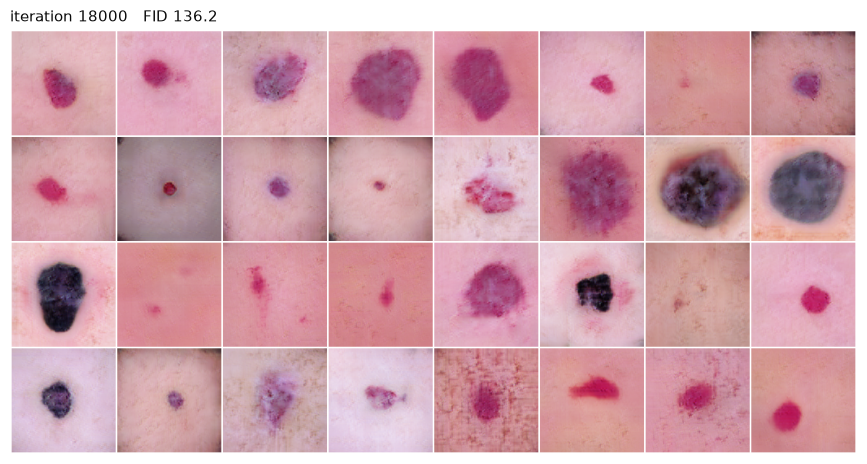

it  18000/20000 | D 1.807 G 0.209 | r_t 0.49 | FID 136.2 | 26.3 min, ETA 2.9 min
it  18500/20000 | D 1.806 G 0.233 | r_t 0.48 | 27.0 min, ETA 2.2 min
it  19000/20000 | D 1.806 G 0.227 | r_t 0.47 | 27.8 min, ETA 1.5 min
it  19500/20000 | D 1.790 G 0.217 | r_t 0.48 | 28.5 min, ETA 0.7 min


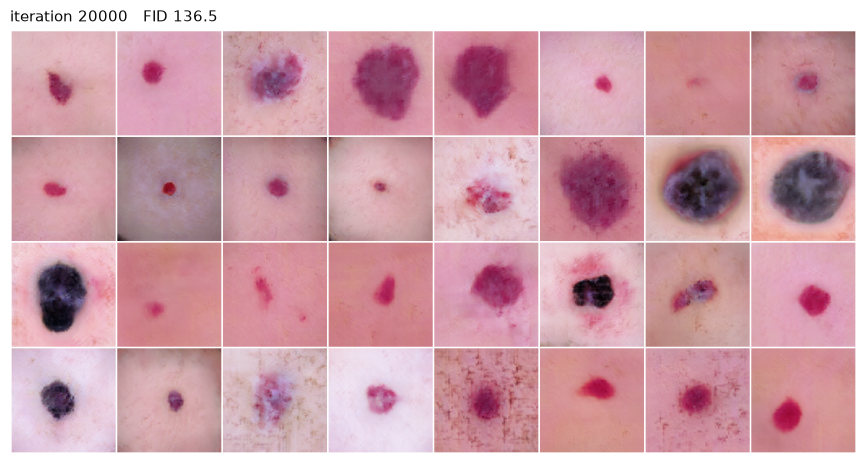

it  20000/20000 | D 1.797 G 0.226 | r_t 0.47 | FID 136.5 | 29.2 min, ETA 0.0 min


In [9]:
f_train_v = inception_features(real128_v, DEVICE)
f_heldout_v = inception_features(heldout128_v, DEVICE)
FID_REF_V = fid_from_features(f_heldout_v, f_train_v)
print(f'Reference FID (real held-out {VASC} vs real training {VASC}): {FID_REF_V:.1f}')

GAN_DIR_V = paths.project_dir / 'models' / f'gan_{VASC}'
cfg_v = GANConfig(img_size=IMG, iters=20000, batch_size=32, lr_g=1e-4, lr_d=4e-4, d_steps=2,
                  eval_every=2000, log_every=500, fid_samples=500, seed=42)
hist_v = train_gan(cfg_v, real128_v, GAN_DIR_V, DEVICE, fid_ref_features=f_train_v, resume=True,
                   show=lambda grid, title: show_image(grid, title, width=11))

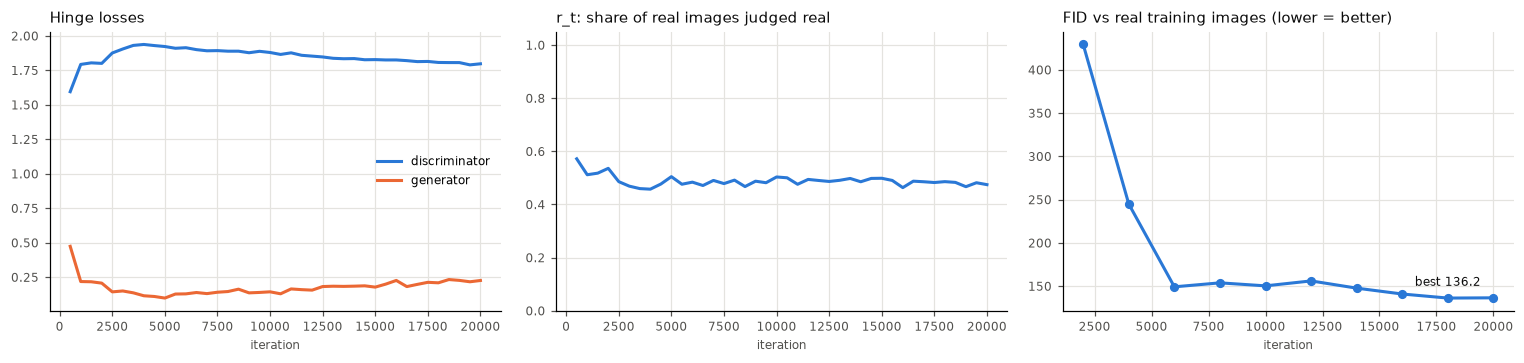

Best VASC generator: iteration 18000, FID 136.2   (real-vs-real reference: 119.8)


In [10]:
plot_gan_history(hist_v, FIG / 'day5_vasc_gan_training.png')
best_v = torch.load(GAN_DIR_V / 'G_best.pt', map_location='cpu', weights_only=False)
print(f"Best VASC generator: iteration {best_v['iter']}, FID {best_v['fid']:.1f}   (real-vs-real reference: {FID_REF_V:.1f})")

### 3c · Generate → memorisation check → filter to 500

Same rules as Day 3: drop near-copies of training images and the 25 % most unusual candidates, keep 500 at random.

Median distance generated -> nearest real: 0.618 | real -> nearest other real lesion: 0.561


,candidates
status,
kept,995
selected,500
outlier,499
copy,6


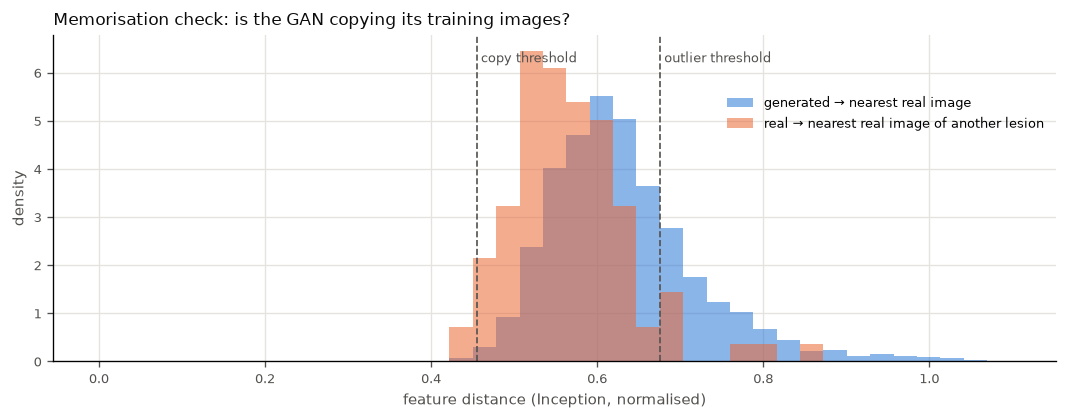

Saved gan_VASC_500.npy (500, 224, 224, 3)


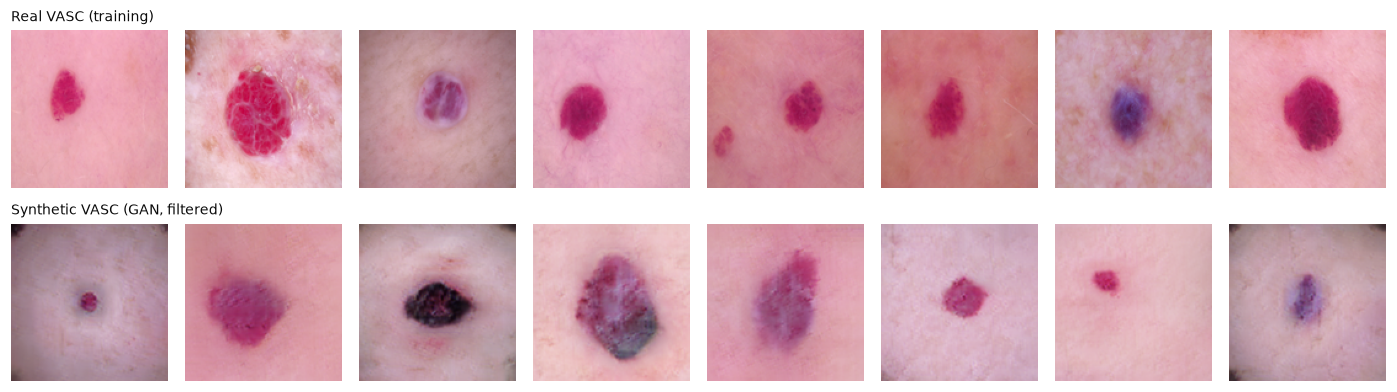

In [11]:
gan_file = synthetic_path(paths, 'gan', VASC, N_EXTRA)
G_v = load_generator(GAN_DIR_V / 'G_best.pt', DEVICE)
cand_v = generate(G_v, 2000, DEVICE, seed=1)
f_cand_v = inception_features(cand_v, DEVICE)
d_rr_v = real_real_nn(f_train_v, lesions_v)
d_gr_v, nn_idx_v = gen_real_nn(f_cand_v, f_train_v)
chosen_v, info_v, thr_v = select_synthetic(f_cand_v, f_train_v, lesions_v, n_keep=N_EXTRA, copy_pct=5,
                                           drop_far_frac=0.25, seed=42)
print(f'Median distance generated -> nearest real: {np.median(d_gr_v):.3f} | real -> nearest other real lesion: {np.median(d_rr_v):.3f}')
display(info_v.status.value_counts().rename('candidates').to_frame())
plot_nn_distances(d_rr_v, d_gr_v, thr_v, FIG / 'day5_vasc_memorisation_check.png')

if gan_file.exists():
    gan_v = np.load(gan_file)        # keep the set the VASC runs were trained on, if they already started
    print('Already saved - using the existing', gan_file.name)
else:
    gan128_v = cand_v[chosen_v]
    gan_v = resize_uint8(gan128_v, 224)
    np.save(syn_dir / f'gan_{VASC}_{N_EXTRA}_128.npy', gan128_v)
    np.save(gan_file, gan_v)
    prov_v = info_v.loc[chosen_v].copy()
    prov_v['nearest_real_image_id'] = train_v.image_id.to_numpy()[prov_v.nearest_real_pos]
    prov_v.drop(columns='nearest_real_pos').to_csv(syn_dir / f'gan_{VASC}_{N_EXTRA}_provenance.csv', index=False)
    print('Saved', gan_file.name, gan_v.shape)

rng = np.random.default_rng(3)
image_rows([real128_v[rng.choice(len(real128_v), 8, replace=False)],
            resize_uint8(gan_v[rng.choice(len(gan_v), 8, replace=False)], IMG)],
           [f'Real {VASC} (training)', f'Synthetic {VASC} (GAN, filtered)'], out=FIG / 'day5_vasc_real_vs_synthetic.png')

In [12]:
rows = [{'image set': f'Real held-out {VASC} (reference)', 'n': len(heldout128_v), 'FID (size-matched)': FID_REF_V, '± sd': 0.0}]
for name, arr in [('GAN - filtered (final 500)', gan_v), ('SMOTE blends', smote_v)]:
    m, s = matched_fid(inception_features(resize_uint8(arr, IMG), DEVICE), f_train_v, len(heldout128_v), draws=10)
    rows.append({'image set': name, 'n': len(arr), 'FID (size-matched)': m, '± sd': s})
fid_v = pd.DataFrame(rows).set_index('image set').round(1)
fid_v.to_csv(paths.results_dir / 'day5_vasc_fid.csv')
display(fid_v)

other_idx = np.random.default_rng(0).choice(train_df.loc[train_df.label != VASC, 'cache_idx'].to_numpy(), 500, replace=False)
shortcuts_v = shortcut_table({f'Real {VASC} (training)': np.stack([images[i] for i in train_v.cache_idx]),
                              'Real other classes (500 random)': np.stack([images[i] for i in other_idx]),
                              f'GAN {VASC} (500)': gan_v, f'SMOTE {VASC} (500)': smote_v})
shortcuts_v.to_csv(paths.results_dir / 'day5_vasc_shortcut_check.csv')
display(shortcuts_v)

,n,FID (size-matched),± sd
image set,,,
Real held-out VASC (reference),43,119.8,0.0
GAN - filtered (final 500),500,156.6,3.2
SMOTE blends,500,78.2,4.1


,n,mean R,mean G,mean B,redness (R−G),sharpness (Laplacian var)
Real VASC (training),99,197.8,148.3,161.3,49.5,39.7
Real other classes (500 random),500,192.1,138.4,145.0,53.7,66.4
GAN VASC (500),500,201.3,153.8,166.8,47.4,10.2
SMOTE VASC (500),500,198.1,147.7,160.6,50.4,26.7


## 4 · Part C — 5 methods × 3 seeds on VASC

15 training runs, ~3–4 min each on the laptop. Only progress lines are printed; every run's files are saved under
`results/runs/vasc_…`. Finished runs are skipped, so this cell is safe to re-run.

In [13]:
import gc                                   # free the GAN candidates before the long training loop
for _name in ['cand_v', 'f_cand_v', 'G_v']:
    globals().pop(_name, None)
gc.collect()
if DEVICE.type == 'cuda':
    torch.cuda.empty_cache()

for seed in SEEDS:
    for cfg in CONFIG_ORDER:
        run_config(cfg, seed, paths, images, split, VASC, n_extra=N_EXTRA, epochs=EPOCHS, pretrained=PRETRAINED)
print('\nAll VASC runs finished.')


=== Baseline (no aug) | seed 42 | extra VASC samples: 0 ===
Device: cuda | AMP: True | train=6981 (rare VASC: 99) | val=1532 | test=1502
ep 01/15 | loss 0.7049 / val 0.5943 | val acc 0.783 macroF1 0.491 | VASC P 0.85 R 0.50 F1 0.63 (pred 13) | 34s  *best*
ep 02/15 | loss 0.2551 / val 0.6163 | val acc 0.792 macroF1 0.553 | VASC P 1.00 R 0.45 F1 0.62 (pred 10) | 11s  *best*
ep 03/15 | loss 0.0950 / val 0.6619 | val acc 0.811 macroF1 0.580 | VASC P 1.00 R 0.41 F1 0.58 (pred 9) | 12s  *best*
ep 04/15 | loss 0.0263 / val 0.6691 | val acc 0.817 macroF1 0.607 | VASC P 1.00 R 0.55 F1 0.71 (pred 12) | 12s  *best*
ep 05/15 | loss 0.0150 / val 0.6186 | val acc 0.828 macroF1 0.623 | VASC P 1.00 R 0.50 F1 0.67 (pred 11) | 12s  *best*
ep 06/15 | loss 0.0065 / val 0.6313 | val acc 0.824 macroF1 0.615 | VASC P 1.00 R 0.45 F1 0.62 (pred 10) | 12s
ep 07/15 | loss 0.0085 / val 0.6596 | val acc 0.817 macroF1 0.633 | VASC P 1.00 R 0.50 F1 0.67 (pred 11) | 12s  *best*
ep 08/15 | loss 0.0049 / val 0.6516 | 

## 5 · Part D — VASC results

,seeds,Accuracy,Macro-F1,VASC precision,VASC recall,VASC F1,VASC AUROC,VASC caught (all seeds)
method,,,,,,,,
Baseline (no aug),3,0.814 ± 0.012,0.673 ± 0.013,0.868 ± 0.053,0.698 ± 0.073,0.771 ± 0.029,0.963 ± 0.002,44 / 63
Oversample only,3,0.820 ± 0.020,0.677 ± 0.037,0.963 ± 0.064,0.698 ± 0.073,0.806 ± 0.036,0.977 ± 0.010,44 / 63
Classic aug,3,0.826 ± 0.005,0.696 ± 0.005,0.905 ± 0.029,0.746 ± 0.055,0.817 ± 0.031,0.990 ± 0.002,47 / 63
SMOTE interp.,3,0.827 ± 0.008,0.696 ± 0.012,0.874 ± 0.078,0.762 ± 0.048,0.814 ± 0.061,0.977 ± 0.008,48 / 63
GAN aug,3,0.820 ± 0.003,0.692 ± 0.005,0.957 ± 0.037,0.714 ± 0.048,0.818 ± 0.044,0.973 ± 0.009,45 / 63


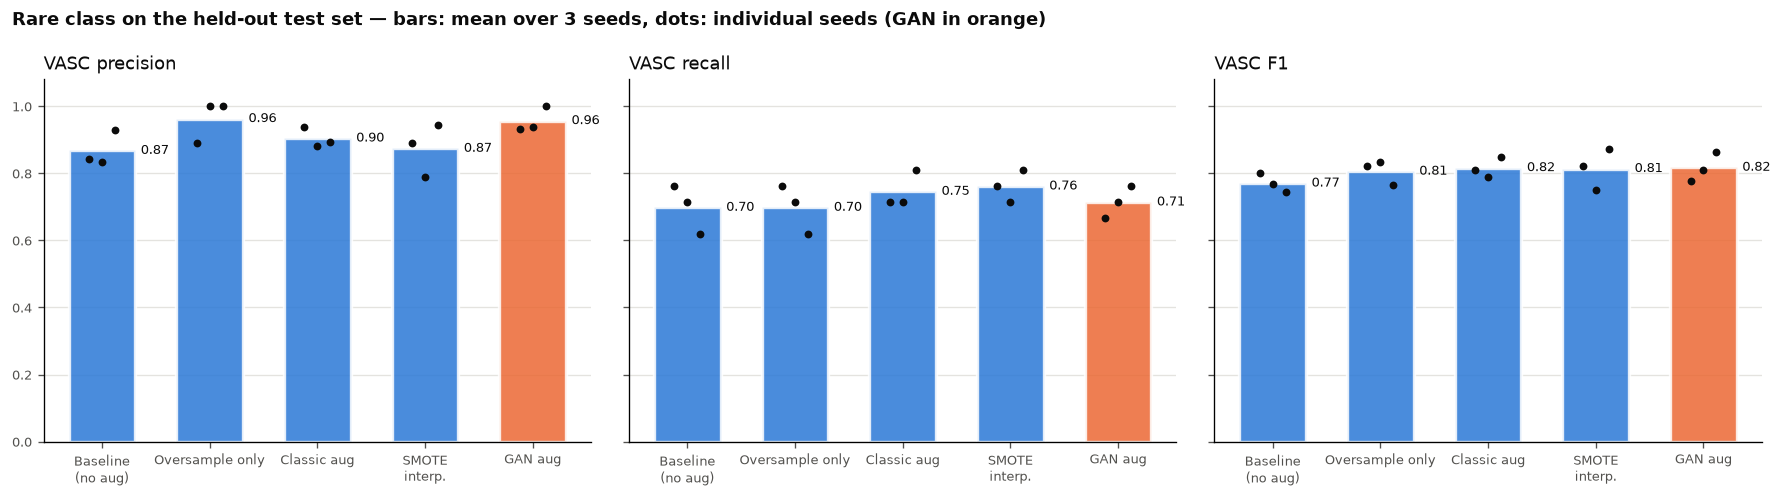

In [14]:
log_v = load_log(paths, VASC)
summary_v = seed_summary(log_v, VASC)
summary_v.to_csv(paths.results_dir / 'day5_vasc_comparison.csv')
display(summary_v)
plot_seed_comparison(log_v, VASC, FIG / 'day5_vasc_comparison.png')

In [15]:
paired_f1_v = paired_vs_baseline(log_v, 'rare_f1')
paired_f1_v.to_csv(paths.results_dir / 'day5_vasc_paired_f1.csv')
print(f'Change in {VASC} F1 vs the baseline with the same seed:')
display(paired_f1_v)
print(f'\nChange in {VASC} recall vs the baseline with the same seed:')
display(paired_vs_baseline(log_v, 'rare_recall'))
preds_v = load_predictions(paths, log_v)
fp_v = false_positive_sources(preds_v, VASC)
fp_v.to_csv(paths.results_dir / 'day5_vasc_false_alarms.csv')
print(f'\nFalse alarms - other diseases wrongly called {VASC} (average per run):')
display(fp_v)

Change in VASC F1 vs the baseline with the same seed:


,seed 42,seed 43,seed 44,mean change,better,same,worse
method,,,,,,,
Oversample only,0.020,0.064,0.022,0.035,3,0,0
Classic aug,0.011,0.020,0.107,0.046,3,0,0
SMOTE interp.,0.020,-0.019,0.129,0.043,2,0,1
GAN aug,-0.022,0.042,0.122,0.047,2,0,1



Change in VASC recall vs the baseline with the same seed:


,seed 42,seed 43,seed 44,mean change,better,same,worse
method,,,,,,,
Oversample only,0.000,0.0,0.000,0.000,0,3,0
Classic aug,-0.048,0.0,0.191,0.048,1,1,1
SMOTE interp.,0.000,0.0,0.191,0.064,1,2,0
GAN aug,-0.095,0.0,0.143,0.016,1,1,1



False alarms - other diseases wrongly called VASC (average per run):


,Baseline (no aug),Oversample only,Classic aug,SMOTE interp.,GAN aug
label,,,,,
MEL,0.0,0.0,0.0,0.0,0.0
NV,1.0,0.3,1.0,0.7,0.3
BCC,1.0,0.3,0.7,1.7,0.3
AKIEC,0.0,0.0,0.0,0.0,0.0
BKL,0.0,0.0,0.0,0.0,0.0
DF,0.3,0.0,0.0,0.0,0.0
TOTAL false alarms,2.3,0.6,1.7,2.4,0.6


### The threshold test on VASC

Baseline (no aug)  seed 42: threshold 0.14 | test VASC F1 0.80 (default) -> 0.70 (tuned) | caught 16 -> 16
Baseline (no aug)  seed 43: threshold 0.12 | test VASC F1 0.77 (default) -> 0.77 (tuned) | caught 15 -> 17
Baseline (no aug)  seed 44: threshold 0.03 | test VASC F1 0.74 (default) -> 0.67 (tuned) | caught 13 -> 18
Oversample only    seed 42: threshold 0.06 | test VASC F1 0.82 (default) -> 0.79 (tuned) | caught 16 -> 17
Oversample only    seed 43: threshold 0.25 | test VASC F1 0.83 (default) -> 0.83 (tuned) | caught 15 -> 15
Oversample only    seed 44: threshold 0.25 | test VASC F1 0.76 (default) -> 0.78 (tuned) | caught 13 -> 14
Classic aug        seed 42: threshold 0.20 | test VASC F1 0.81 (default) -> 0.79 (tuned) | caught 15 -> 15
Classic aug        seed 43: threshold 0.36 | test VASC F1 0.79 (default) -> 0.77 (tuned) | caught 15 -> 15
Classic aug        seed 44: threshold 0.15 | test VASC F1 0.85 (default) -> 0.76 (tuned) | caught 17 -> 19
SMOTE interp.      seed 42: threshold

,seeds,VASC F1 — default,VASC F1 — tuned threshold,recall — tuned,precision — tuned,false alarms / run — tuned,threshold (mean),VASC AP (threshold-free)
method,,,,,,,,
Baseline (no aug),3,0.771 ± 0.029,0.712 ± 0.055,0.810 ± 0.048,0.642 ± 0.097,10.0,0.10,0.823 ± 0.017
Oversample only,3,0.806 ± 0.036,0.801 ± 0.029,0.730 ± 0.073,0.902 ± 0.117,2.0,0.19,0.865 ± 0.018
Classic aug,3,0.817 ± 0.031,0.773 ± 0.015,0.778 ± 0.110,0.790 ± 0.120,5.0,0.24,0.867 ± 0.033
SMOTE interp.,3,0.814 ± 0.061,0.789 ± 0.060,0.825 ± 0.055,0.759 ± 0.087,5.7,0.12,0.874 ± 0.023
GAN aug,3,0.818 ± 0.044,0.782 ± 0.040,0.778 ± 0.099,0.794 ± 0.039,4.3,0.13,0.836 ± 0.030


,seed 42,seed 43,seed 44,mean change,better,same,worse
method,,,,,,,
Oversample only,0.095,0.061,0.111,0.089,3,0,0
Classic aug,0.094,-0.003,0.093,0.061,2,0,1
SMOTE interp.,0.161,-0.029,0.099,0.077,2,0,1
GAN aug,0.041,0.037,0.133,0.070,3,0,0


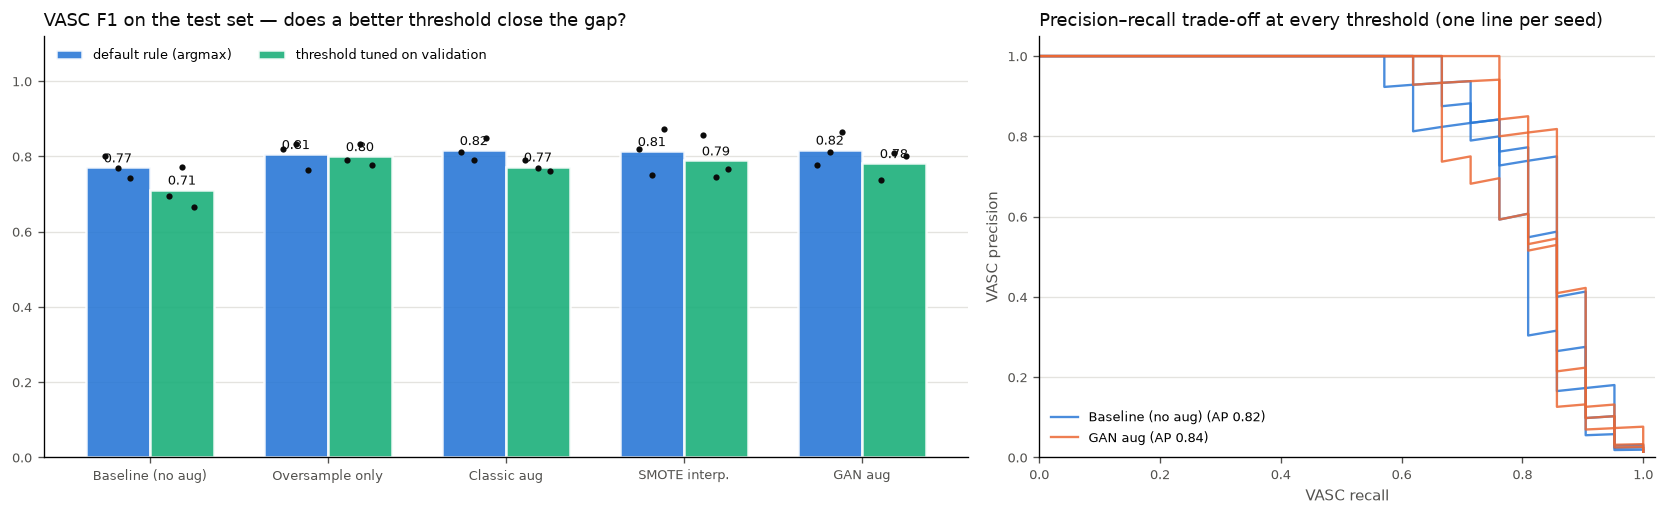

In [16]:
study_v = threshold_study(paths, log_v, images, split, VASC, DEVICE)
study_v.to_csv(paths.results_dir / 'day5_threshold_VASC_runs.csv', index=False)
thr_v_table = threshold_summary(study_v, VASC)
thr_v_table.to_csv(paths.results_dir / 'day5_threshold_VASC.csv')
display(thr_v_table)
paired_thr_v = paired_tuned(study_v)
display(paired_thr_v)
plot_threshold_effect(study_v, paths, VASC, FIG / 'day5_threshold_VASC.png')

## 6 · Part E — both diseases side by side

The project's final picture: the same five methods on two different rare diseases.

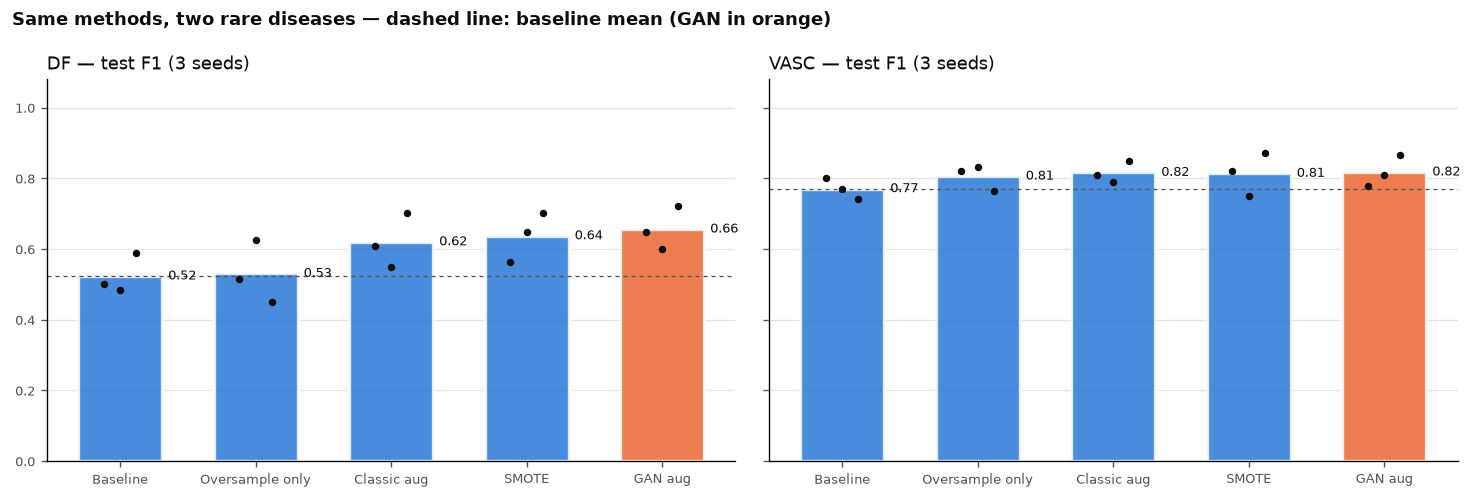

DF                                                       VASC                                                    
                      F1  F1 sd recall precision F1 (tuned threshold)     AP     F1  F1 sd recall precision F1 (tuned threshold)     AP
Baseline (no aug)  0.524  0.057  0.433     0.685                0.574  0.615  0.771  0.029  0.698     0.868                0.712  0.823
Oversample only    0.531  0.088  0.417     0.732                0.588  0.692  0.806  0.036  0.698     0.963                0.801  0.865
Classic aug        0.620  0.077  0.633     0.618                0.642  0.681  0.817  0.031  0.746     0.905                0.773  0.867
SMOTE interp.      0.637  0.071  0.550     0.767                0.650  0.689  0.814  0.061  0.762     0.874                0.789  0.874
GAN aug            0.656  0.062  0.550     0.833                0.626  0.734  0.818  0.044  0.714     0.957                0.782  0.836

In [17]:
plot_two_diseases({DF: log_df, VASC: log_v}, FIG / 'day5_two_diseases_f1.png')

def stats(log, study, cfg):
    g, s = log[log.config == cfg], study[study.config == cfg]
    return {'F1': round(g.rare_f1.mean(), 3), 'F1 sd': round(g.rare_f1.std(ddof=1), 3),
            'recall': round(g.rare_recall.mean(), 3), 'precision': round(g.rare_precision.mean(), 3),
            'F1 (tuned threshold)': round(s.tuned_f1.mean(), 3) if len(s) else None,
            'AP': round(s.test_AP.mean(), 3) if len(s) else None}

both = pd.concat({rare: pd.DataFrame({CONFIGS[c]['label']: stats(lg, st, c) for c in CONFIG_ORDER}).T
                  for rare, lg, st in [(DF, log_df, study_df), (VASC, log_v, study_v)]}, axis=1)
both.to_csv(paths.results_dir / 'day5_two_diseases.csv')
display(both)

In [18]:
def best_of(table, col):
    return table[col].astype(float).idxmax()

day5 = {
    'threshold_DF': {'methods': thr_df.to_dict(orient='index'), 'paired_tuned_f1': paired_thr_df.to_dict(orient='index')},
    'threshold_VASC': {'methods': thr_v_table.to_dict(orient='index'), 'paired_tuned_f1': paired_thr_v.to_dict(orient='index')},
    'vasc': {'gan_best_iter': int(best_v['iter']), 'gan_best_fid': round(float(best_v['fid']), 1),
             'fid_reference': round(float(FID_REF_V), 1), 'train_images': int(len(real128_v)),
             'test_images': int(log_v.rare_support.iloc[0]), 'summary': summary_v.to_dict(orient='index')},
    'two_diseases': {r: both[r].to_dict(orient='index') for r in (DF, VASC)},
}
(paths.results_dir / 'day5_summary.json').write_text(json.dumps(day5, indent=2, default=str))
for rare in (DF, VASC):
    t = both[rare]
    print(f"{rare}: best mean F1 = {best_of(t, 'F1')} ({t['F1'].max():.3f}) | "
          f"best with tuned threshold = {best_of(t, 'F1 (tuned threshold)')} ({t['F1 (tuned threshold)'].max():.3f}) | "
          f"best AP = {best_of(t, 'AP')} ({t['AP'].max():.3f})")

DF: best mean F1 = GAN aug (0.656) | best with tuned threshold = SMOTE interp. (0.650) | best AP = GAN aug (0.734)
VASC: best mean F1 = GAN aug (0.818) | best with tuned threshold = Oversample only (0.801) | best AP = SMOTE interp. (0.874)


## ✅ Day 5 done

Save the notebook (`Ctrl + S`) and send it to Claude — the file is
`C:\rare-disease-aug\notebooks\05_day5_threshold_and_vasc.ipynb`. Claude will check:

* **Part A** — does the GAN stay ahead of a tuned-threshold baseline on DF?
* **Parts B–D** — the VASC GAN (samples, memorisation check) and whether the DF pattern repeats on VASC
* **Part E** — the combined picture that goes into the app and the write-up

Next and last: Day 6 — the RareLens app, README, GitHub and the write-up.